In [1]:
# Libraries

import adi
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score


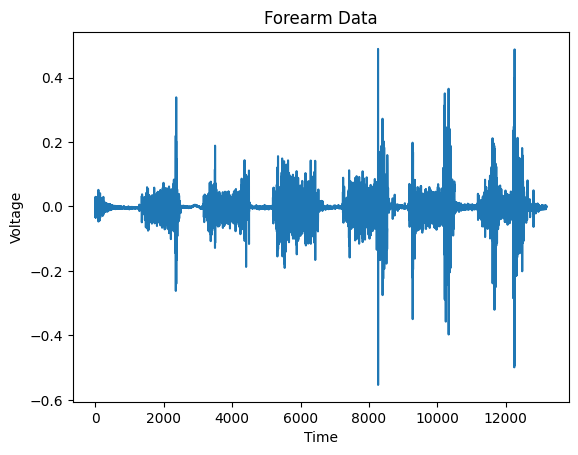

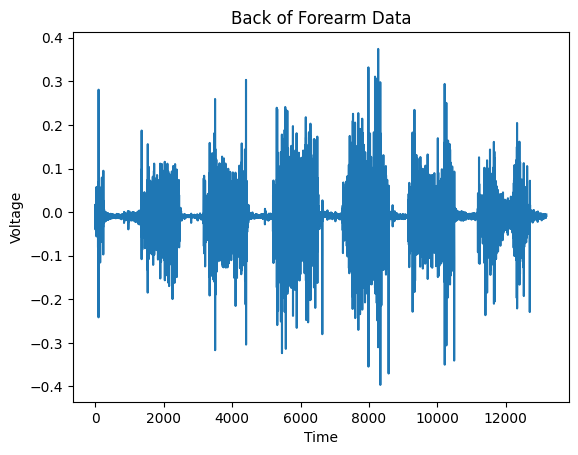

In [2]:

# Reading the labChart file 
f = adi.read_file(r'lab_data.adicht')

# Storing the data of the two channels
record_id = 1
data_1 = f.channels[2].get_data(record_id)
data_2 = f.channels[3].get_data(record_id)
   
# Plotting data_1 in the first figure
plt.figure(1)
plt.plot(data_1)
plt.title('Forearm Data')
plt.xlabel('Time')
plt.ylabel('Voltage')

# Plotting data_2 in the second figure
plt.figure(2)
plt.plot(data_2)
plt.title('Back of Forearm Data')
plt.xlabel('Time')
plt.ylabel('Voltage')

# Showing both plots
plt.show()

### Part A

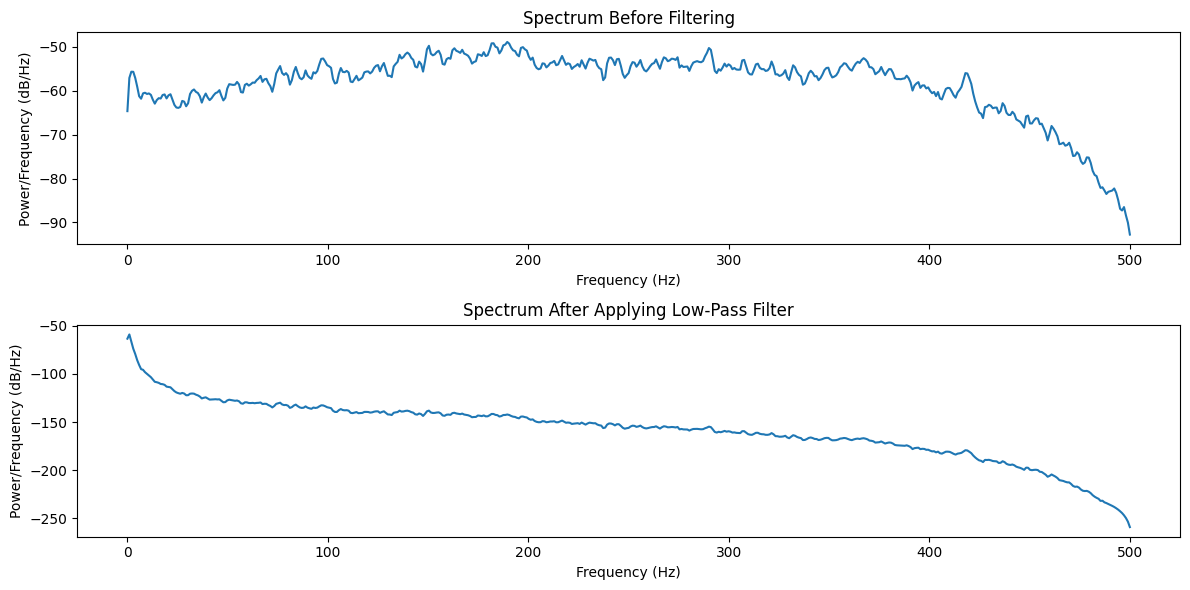

In [3]:
fs = 1000 
# Butterworth filter
cutoff_frequency = 1
order = 1 
b, a = butter(order, cutoff_frequency, fs=fs, btype='low')
filtered_emg = filtfilt(b, a, data_1)

# Before filtering
frequencies_before, spectrum_before = welch(data_1, fs=fs, nperseg=1024)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(frequencies_before, 10 * np.log10(spectrum_before))
plt.title('Spectrum Before Filtering')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')

# After filtering
frequencies_after, spectrum_after = welch(filtered_emg, fs=fs, nperseg=1024)
plt.subplot(2, 1, 2)
plt.plot(frequencies_after, 10 * np.log10(spectrum_after))
plt.title('Spectrum After Applying Low-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')

# Showing both plots
plt.tight_layout()
plt.show()

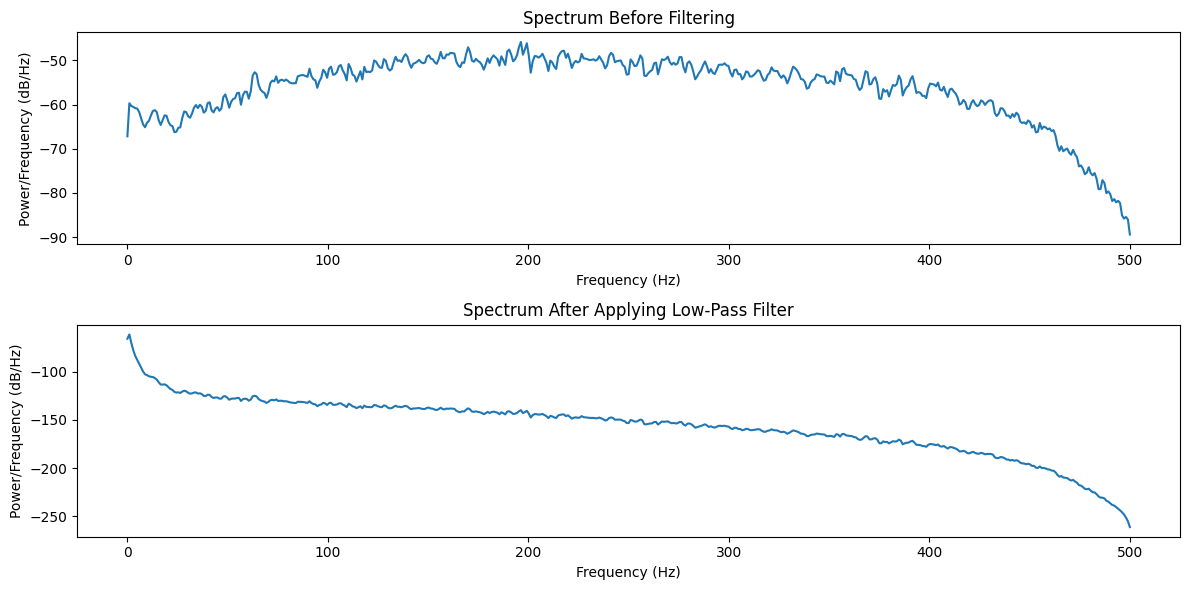

In [4]:
# For the Tricep Signal

filtered_emg2 = filtfilt(b, a, data_2)

# Before filtering
frequencies_before, spectrum_before = welch(data_2, fs=fs, nperseg=1024)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(frequencies_before, 10 * np.log10(spectrum_before))
plt.title('Spectrum Before Filtering')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')

# After filtering
frequencies_after2, spectrum_after2 = welch(filtered_emg2, fs=fs, nperseg=1024)
plt.subplot(2, 1, 2)
plt.plot(frequencies_after2, 10 * np.log10(spectrum_after2))
plt.title('Spectrum After Applying Low-Pass Filter')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')

# Showing both plots
plt.tight_layout()
plt.show()

### Part B

In [5]:


combined_data = np.vstack((filtered_emg, filtered_emg2)).T

# Splitting the data (80% training, 20% test)
train_data, test_data = train_test_split(combined_data, test_size=0.2, random_state=42)

# Normalization(Second method)
scaler = StandardScaler()
train_data = train_data.reshape(-1, 1)
test_data = test_data.reshape(-1, 1)
train_data_normalized = scaler.fit_transform(train_data)
test_data_normalized = scaler.transform(test_data)

### Part C 

In [6]:


def rolling_window(data, window_length, step):
    windows = []
    for i in range(0, len(data) - window_length, step):
        window = data[i:i + window_length]
        windows.append(window)
    return windows

f_sampling = 320
w = int(0.21*f_sampling)
step = int(0.004*f_sampling)

Data_1 = pd.DataFrame(train_data)
Data_1['Time'] = np.arange(0, len(train_data)/f_sampling, 1/f_sampling)

Data_2 = pd.DataFrame(test_data)
Data_2['Time'] = np.arange(0, len(test_data)/f_sampling, 1/f_sampling)

windows_1 = rolling_window(Data_1['Time'], w, step)
windows_2 = rolling_window(Data_2['Time'], w, step)


df = pd.DataFrame()
df_test = pd.DataFrame() 

for window in windows_1:
    time_start = window.iloc[0]
    time_end = window.iloc[-1]
#     print(window)
    if 0 <= time_start <= 5 and 0 <= time_end <= 5:
        label_name = "activity 1"
    elif 5 < time_start <= 10 and 5 < time_end <= 10:
        label_name = "activity 2"
    elif 10 < time_start <= 15 and 10 < time_end <= 15:
        label_name = "activity 3"
    elif 15 < time_start <= 20 and 15 < time_end <= 20:
        label_name = "activity 4"
    elif 20 < time_start <= 25 and 20 < time_end <= 25:
        label_name = "activity 5"
    elif 25 < time_start <= 30 and 25 < time_end <= 30:
        label_name = "activity 6"
    elif 30 < time_start <= 35 and 30 < time_end <= 35:
        label_name = "activity 7"
    elif 35 < time_start <= 40 and 35 < time_end <= 40:
        label_name = "activity 8"
    elif 40 < time_start <= 45 and 40 < time_end <= 45:
        label_name = "activity 9"
    elif 45 < time_start <= 50 and 45 < time_end <= 50:
        label_name = "activity 10"
    elif 50 < time_start <= 55 and 50 < time_end <= 55:
        label_name = "activity 11"
    elif 55 < time_start <= 60 and 60 < time_end <= 65:
        label_name = "activity 12"
    elif time_end > 65:
        label_name = "activity 13"
    else:
        label_name = "unknown"  
    
    # Std
    std = window.std()

    # Mean Absolute
    abs1 = window.abs()
    mav = abs1.mean()

    # Var
    var = window.var()

    # Sum Absolute
    iav = abs1.sum()
    
    
    #df = df.append({'Label': label_name, 'MAV': mav, 'STD': std, 'VAR': var, 'IAV': iav}, ignore_index=True)
    new_row = pd.DataFrame({'Label': [label_name], 'MAV': [mav], 'STD': [std], 'VAR': [var], 'IAV': [iav]})
    df = pd.concat([df, new_row], ignore_index=True)

    
    

display(df)

,Label,MAV,STD,VAR,IAV
0,activity 1,0.103125,0.060891,0.003708,6.909375
1,activity 1,0.106250,0.060891,0.003708,7.118750
2,activity 1,0.109375,0.060891,0.003708,7.328125
3,activity 1,0.112500,0.060891,0.003708,7.537500
4,activity 1,0.115625,0.060891,0.003708,7.746875
...,...,...,...,...,...
21026,activity 13,65.809375,0.060891,0.003708,4409.228125
21027,activity 13,65.812500,0.060891,0.003708,4409.437500
21028,activity 13,65.815625,0.060891,0.003708,4409.646875
21029,activity 13,65.818750,0.060891,0.003708,4409.856250


In [7]:
for window in windows_2:
    time_start = window.iloc[0]
    time_end = window.iloc[-1]
#     print(window)
    if 0 <= time_start <= 5 and 0 <= time_end <= 5:
        label_name = "activity 1"
    elif 5 < time_start <= 10 and 5 < time_end <= 10:
        label_name = "activity 2"
    elif 10 < time_start <= 15 and 10 < time_end <= 15:
        label_name = "activity 3"
    elif 15 < time_start <= 20 and 15 < time_end <= 20:
        label_name = "activity 4"
    elif 20 < time_start <= 25 and 20 < time_end <= 25:
        label_name = "activity 5"
    elif 25 < time_start <= 30 and 25 < time_end <= 30:
        label_name = "activity 6"
    elif 30 < time_start <= 35 and 30 < time_end <= 35:
        label_name = "activity 7"
    elif 35 < time_start <= 40 and 35 < time_end <= 40:
        label_name = "activity 8"
    elif 40 < time_start <= 45 and 40 < time_end <= 45:
        label_name = "activity 9"
    elif 45 < time_start <= 50 and 45 < time_end <= 50:
        label_name = "activity 10"
    elif 50 < time_start <= 55 and 50 < time_end <= 55:
        label_name = "activity 11"
    elif 55 < time_start <= 60 and 60 < time_end <= 65:
        label_name = "activity 12"
    elif time_end > 65:
        label_name = "activity 13"
    else:
        label_name = "unknown"  
    
    # Std
    std = window.std()

    # Mean Absolute
    abs1 = window.abs()
    mav = abs1.mean()

    # Var
    var = window.var()

    # Sum Absolute
    iav = abs1.sum()
    
    #df_test = df_test.append({'Label': label_name, 'MAV': mav, 'STD': std, 'VAR': var, 'IAV': iav}, ignore_index=True)
    new_row = pd.DataFrame({'Label': [label_name], 'MAV': [mav], 'STD': [std], 'VAR': [var], 'IAV': [iav]})
    df_test = pd.concat([df_test, new_row], ignore_index=True)
    
display(df_test)

,Label,MAV,STD,VAR,IAV
0,activity 1,0.103125,0.060891,0.003708,6.909375
1,activity 1,0.106250,0.060891,0.003708,7.118750
2,activity 1,0.109375,0.060891,0.003708,7.328125
3,activity 1,0.112500,0.060891,0.003708,7.537500
4,activity 1,0.115625,0.060891,0.003708,7.746875
...,...,...,...,...,...
5204,activity 4,16.365625,0.060891,0.003708,1096.496875
5205,activity 4,16.368750,0.060891,0.003708,1096.706250
5206,activity 4,16.371875,0.060891,0.003708,1096.915625
5207,activity 4,16.375000,0.060891,0.003708,1097.125000


### Part D

In [8]:

train_data = df[['MAV', 'STD', 'VAR', 'IAV']]
train_labels = df['Label'].astype(str)

test_data = df_test[['MAV', 'STD', 'VAR', 'IAV']]
test_labels = df_test['Label'].astype(str)

### Part E

In [9]:
# KNN
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(train_data, train_labels)
knn_predictions = knn_classifier.predict(test_data)

knn_conf_matrix = confusion_matrix(test_labels, knn_predictions)
knn_accuracy = accuracy_score(test_labels, knn_predictions)

print("\nKNN Confusion Matrix:")
print(knn_conf_matrix)
print("KNN Accuracy:", knn_accuracy)


KNN Confusion Matrix:
[[1535    0    0    0    0]
 [   0 1534    0    0    0]
 [   0    0 1534    0    0]
 [   0    0    0  408    0]
 [   0    0    0    0  198]]
KNN Accuracy: 1.0


In [10]:
#LDA
lda_classifier = LinearDiscriminantAnalysis()
lda_classifier.fit(train_data, train_labels)
lda_predictions = lda_classifier.predict(test_data)

lda_conf_matrix = confusion_matrix(test_labels, lda_predictions)
lda_accuracy = accuracy_score(test_labels, lda_predictions)

print("LDA Confusion Matrix:")
print(lda_conf_matrix)
print("LDA Accuracy:", lda_accuracy)

LDA Confusion Matrix:
[[1535    0    0    0    0]
 [   0 1534    0    0    0]
 [   0    0 1534    0    0]
 [   0    0    0  408    0]
 [  22   66   81   29    0]]
LDA Accuracy: 0.9619888654252255
